In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [4]:
# -----------------IMPORT 5 LAKHS ROWS ---------------------------
Telecom_Customer = r"D:\Telecom_Customer_Churn\telecom_customer_churn_big.csv"
df = pd.read_csv(Telecom_Customer)
print(df)

        customer_id  gender   age       city signup_date  tenure_months  \
0       CUST1000000  Female 29.00    Chennai  16-02-2023             41   
1       CUST1000001  Female 64.00    Lucknow  22-04-2022             51   
2       CUST1000002  Female 61.00  Ahmedabad  24-09-2021             58   
3       CUST1000003    Male 19.00     Jaipur  14-09-2023             34   
4       CUST1000004    Male 26.00  Bengaluru  27-05-2021             62   
...             ...     ...   ...        ...         ...            ...   
503995  CUST1241326    Male 47.00    Chennai  10-06-2024             25   
503996  CUST1099140    Male 28.00       Pune  18-11-2022             44   
503997  CUST1195940  Female 42.00  Ahmedabad  26-02-2021             65   
503998  CUST1064420    Male 59.00       Pune  05-06-2025             13   
503999  CUST1036796  Female 40.00      Delhi  24-09-2021             58   

         contract_type internet_service payment_method paperless_billing  \
0             One year 

In [11]:
# 2. DATA UNDERSTANDING
# ---------------------------------------------------------------
print("--- Info ---")
df.info()
 
print("--- Summary statistics ---")
print(df.describe())
 
print("--- Missing values ---")
missing = df.isnull().sum()
print(pd.DataFrame({"missing": missing, "percent": (missing / len(df) * 100).round(2)}))
 
print("Duplicate rows:", df.duplicated().sum())
 

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504000 entries, 0 to 503999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   customer_id        504000 non-null  object 
 1   gender             504000 non-null  object 
 2   age                488903 non-null  float64
 3   city               493912 non-null  object 
 4   signup_date        504000 non-null  object 
 5   tenure_months      504000 non-null  int64  
 6   contract_type      504000 non-null  object 
 7   internet_service   504000 non-null  object 
 8   payment_method     504000 non-null  object 
 9   paperless_billing  504000 non-null  object 
 10  support_calls      504000 non-null  int64  
 11  monthly_charges    496457 non-null  float64
 12  total_charges      493923 non-null  float64
 13  churn              504000 non-null  object 
dtypes: float64(3), int64(2), object(9)
memory usage: 53.8+ MB
--- Summary statistics ---
  

In [12]:
# 3.1 Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
 
# 3.2 Standardize text (fix "delhi" vs "Delhi")
df["city"] = df["city"].str.strip().str.title()
 
# 3.3 Outliers in monthly_charges (9999 is not a valid plan price)
df.loc[df["monthly_charges"] > 5000, "monthly_charges"] = np.nan
 
# 3.4 Fill missing values
df["age"] = df["age"].fillna(df["age"].median()).astype(int)
df["city"] = df["city"].fillna("Unknown")
df["monthly_charges"] = df["monthly_charges"].fillna(
    df.groupby("internet_service")["monthly_charges"].transform("median")
)
df["total_charges"] = df["total_charges"].fillna(df["monthly_charges"] * df["tenure_months"])
 
# 3.5 Convert types
for col in ["gender", "city", "contract_type", "internet_service", "payment_method", "paperless_billing", "churn"]:
    df[col] = df[col].astype("category")
 
df["churn_flag"] = (df["churn"] == "Yes").astype(int)
 
print("\nAfter cleaning -> shape:", df.shape, "| nulls:", df.isnull().sum().sum())


After cleaning -> shape: (500010, 15) | nulls: 0


In [21]:
# 5. EXPLORATORY DATA ANALYSIS
# ---------------------------------------------------------------
overall_churn = df["churn_flag"].mean() * 100
print("Overall churn rate: {overall_churn:.2f}%")
 
for col in ["contract_type", "internet_service", "payment_method", "tenure_group", "age_group", "city"]:
    print(f"\nChurn rate by {col}:")
    print((df.groupby(col)["churn_flag"].mean() * 100).sort_values(ascending=False).round(2))

Overall churn rate: {overall_churn:.2f}%

Churn rate by contract_type:
contract_type
Month-to-month   49.13
One year         19.57
Two year         11.78
Name: churn_flag, dtype: float64

Churn rate by internet_service:
internet_service
Fiber   45.24
DSL     27.78
No      19.05
Name: churn_flag, dtype: float64

Churn rate by payment_method:
payment_method
Cash          38.76
Auto-debit    33.94
Net Banking   33.85
UPI           33.79
Credit Card   33.68
Name: churn_flag, dtype: float64

Churn rate by tenure_group:
tenure_group
0-12 m    50.17
13-24 m   43.25
25-48 m   33.99
49-72 m   22.31
Name: churn_flag, dtype: float64

Churn rate by age_group:
age_group
51-65   34.42
26-35   34.36
65+     34.30
36-50   34.24
18-25   34.17
Name: churn_flag, dtype: float64

Churn rate by city:
city
Kolkata     34.52
Bengaluru   34.41
Pune        34.40
Lucknow     34.37
Hyderabad   34.35
Jaipur      34.33
Delhi       34.28
Mumbai      34.24
Chennai     34.21
Ahmedabad   34.07
Unknown     33.77
Name: c

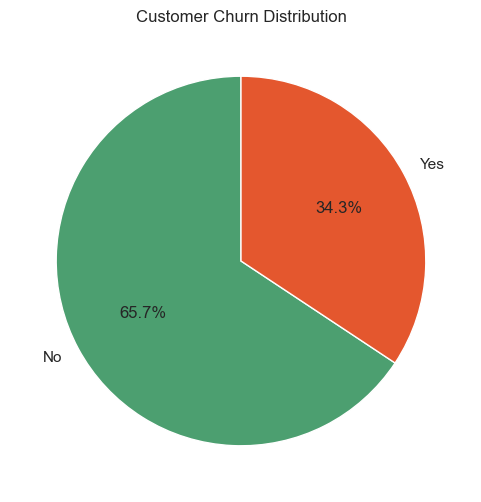

In [23]:
#-----------Churn distribution-----------

plt.figure(figsize=(6, 6))
df["churn"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, colors=["#4C9F70", "#E4572E"])
plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.show()

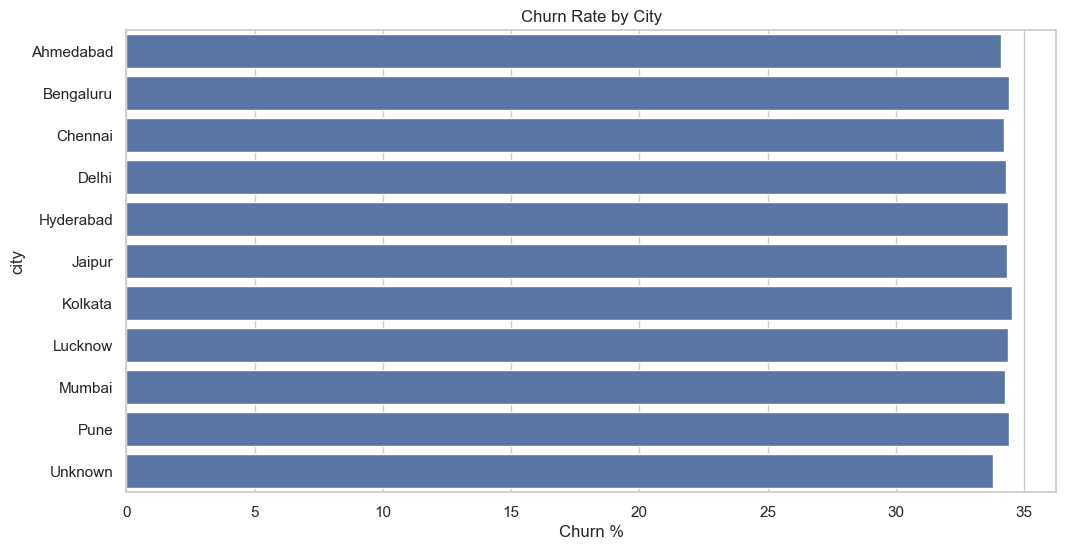

In [25]:
# ------------Churn rate by city--------------

city_rate = (df.groupby("city")["churn_flag"].mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=city_rate.values, y=city_rate.index)
plt.title("Churn Rate by City")
plt.xlabel("Churn %")
plt.show()

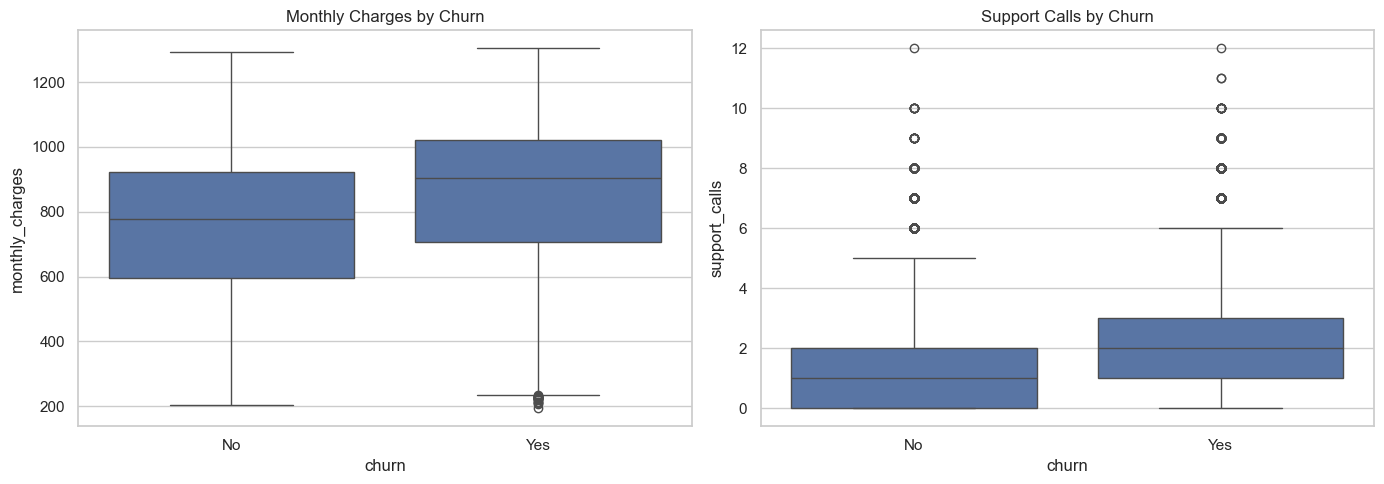

In [26]:
#----------- Boxplots----------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="churn", y="monthly_charges", ax=axes[0])
axes[0].set_title("Monthly Charges by Churn")
sns.boxplot(data=df, x="churn", y="support_calls", ax=axes[1])
axes[1].set_title("Support Calls by Churn")
plt.tight_layout()
plt.show()

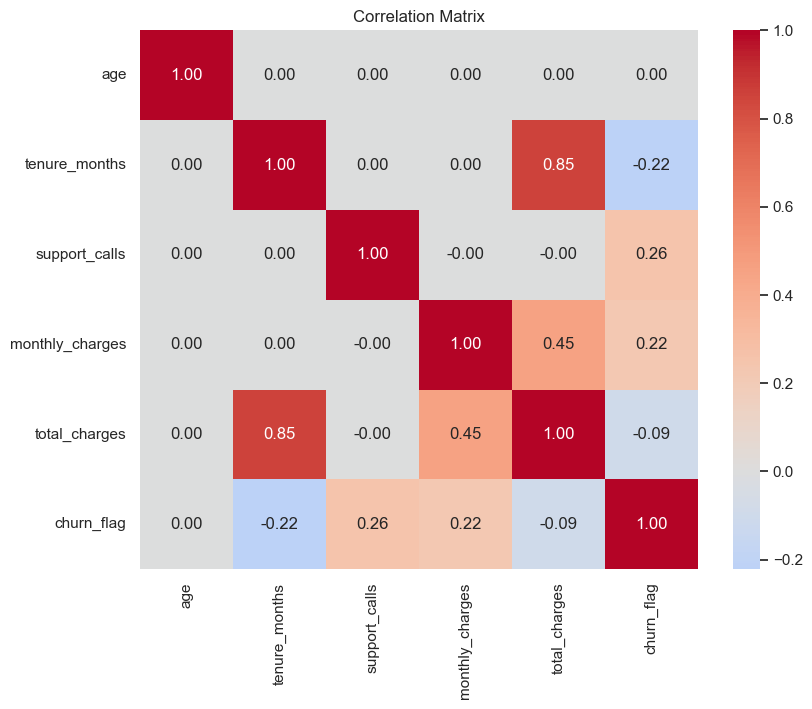

In [27]:
#-----------------Correlation heatmap---------------
num_cols = ["age", "tenure_months", "support_calls", "monthly_charges", "total_charges", "churn_flag"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

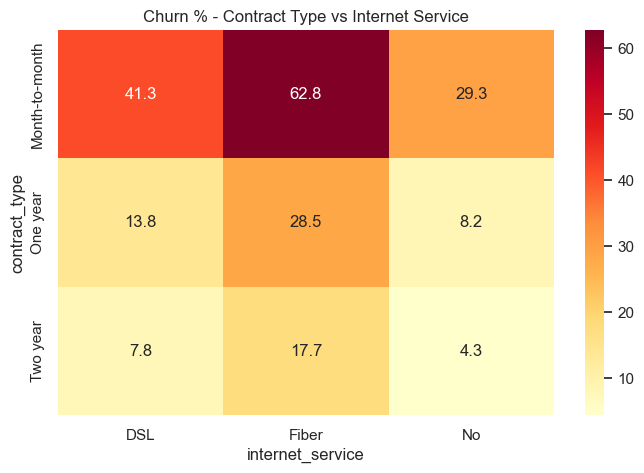

In [29]:
#----------Heatmap: contract x internet service churn rate-----------
pivot = df.pivot_table(index="contract_type", columns="internet_service", values="churn_flag", aggfunc="mean") * 100
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Churn % - Contract Type vs Internet Service")
plt.show()

In [32]:
# 8. KEY INSIGHTS (auto-generated)
# ---------------------------------------------------------------
worst_contract = (df.groupby("contract_type")["churn_flag"].mean() * 100).idxmax()
worst_tenure = (df.groupby("tenure_group")["churn_flag"].mean() * 100).idxmax()
worst_payment = (df.groupby("payment_method")["churn_flag"].mean() * 100).idxmax()
 
print("===== KEY INSIGHTS =====")
print(f"1. Overall churn rate is {overall_churn:.1f}%.")
print(f"2. Highest churn by contract: {worst_contract}.")
print(f"3. Highest churn by tenure: {worst_tenure}.")
print(f"4. Highest churn by payment method: {worst_payment}.")
print("5. Check whether customers with 3+ support calls churn more (high_support_calls).")

===== KEY INSIGHTS =====
1. Overall churn rate is 34.3%.
2. Highest churn by contract: Month-to-month.
3. Highest churn by tenure: 0-12 m.
4. Highest churn by payment method: Cash.
5. Check whether customers with 3+ support calls churn more (high_support_calls).
